In [1]:
import sys
import os
sys.path.append('../')

In [2]:
from dataset import ArtportalenDataModule

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data = ArtportalenDataModule(data_dir='/Users/amee/Library/CloudStorage/GoogleDrive-ameeassad@gmail.com/My Drive/artportalen_goeag', batch_size=4, size=256, mean=mean, std=std)
data.setup_from_coco('../annot/modified_val_annotations.json', '../annot/modified_val_annotations.json')
dataloader = data.train_dataloader()



loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Train: 911 Val: 911
Unique classes in dataset: [2 5 1 4 3]
Number of classes: 5


Batch Size: 4
Image Shape: torch.Size([4, 3, 256, 256])
Labels Shape: torch.Size([4])


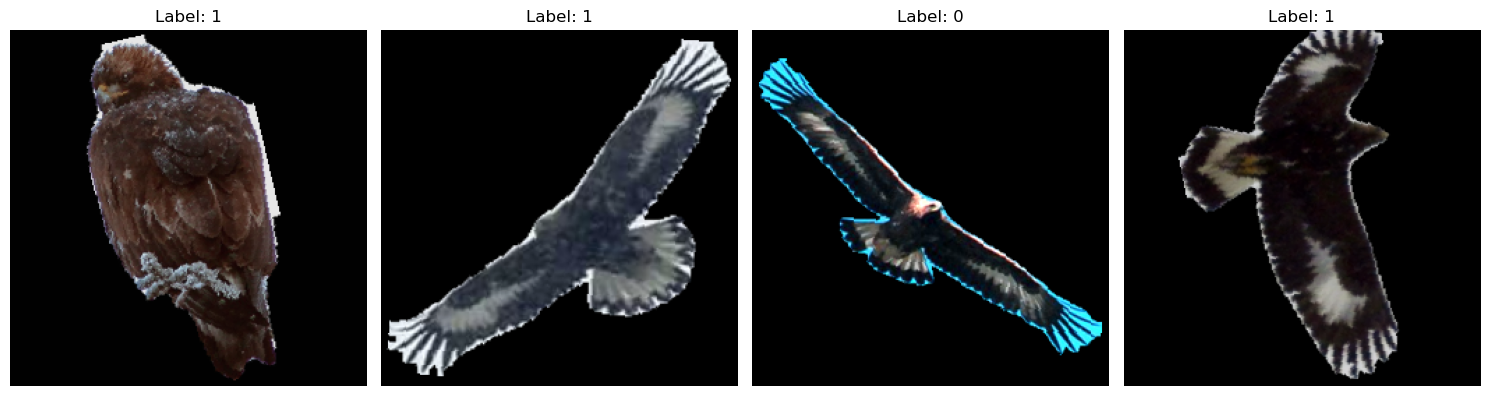

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from dataset import unnormalize

# Fetch a batch of images (assuming batch size is 8 for example)
batch = next(iter(dataloader))
images,labels = batch
print("Batch Size:", images.size(0))
print("Image Shape:", images.shape)
print("Labels Shape:", labels.shape)

# Extract images and labels from the batch
images, labels = batch  # This assumes batch is structured as (images, labels)

# Plot the images
fig, axes = plt.subplots(1, 4, figsize=(15, 7))
axes = axes.flatten()

for i in range(4):  # Assuming batch size is 8
    image_np = unnormalize(images[i], mean, std).permute(1, 2, 0).numpy()
    # image_np = images[i].numpy()  # Convert from PyTorch tensor to numpy array
    # image_np = np.transpose(image_np, (1, 2, 0))  # Convert from (C, H, W) to (H, W, C) for plotting
    label = labels[i].item()  # Convert label tensor to Python scalar using .item()
    ax = axes[i]
    ax.imshow(image_np)
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()